# Stabilizing Deep Networks

Four devices from the lecture, each run on the same ten-layer network and the
same handwritten digits:

1. the scale of the initial weights,
2. skip connections,
3. gradient clipping,
4. learning-rate schedules.

Everything here trains on a laptop CPU in under a minute.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/11-mlp-training/'
for _name in ['SklearnDigits.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(11)
digits = pd.read_csv('SklearnDigits.csv')
y = torch.tensor(digits['target'].to_numpy(), dtype=torch.long)
X = torch.tensor(digits.drop(columns='target').to_numpy(), dtype=torch.float32)
X = (X - X.mean(0)) / (X.std(0) + 1e-6)
print(X.shape, y.shape)

torch.Size([1797, 64]) torch.Size([1797])


## A ten-layer network with switchable tricks

In [2]:
class Deep(nn.Module):
    def __init__(self, residual=False, gain=None, width=64, depth=10):
        super().__init__()
        self.first = nn.Linear(X.shape[1], width)
        self.blocks = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.head = nn.Linear(width, 10)
        self.residual = residual
        if gain is not None:                    # replace the default init
            for layer in [self.first, *self.blocks, self.head]:
                nn.init.normal_(layer.weight, std=gain)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        h = torch.tanh(self.first(x))
        for block in self.blocks:
            out = torch.tanh(block(h))
            h = h + out if self.residual else out
        return self.head(h)

def run(residual=False, gain=None, clip=None, schedule=False, steps=400, lr=0.05, seed=0):
    torch.manual_seed(seed)
    model, loss_fn = Deep(residual, gain), nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = []
    for t in range(steps):
        if schedule:                            # warmup, then cosine
            factor = min(1.0, (t + 1) / 40) * 0.5 * (1 + np.cos(np.pi * t / steps))
            for group in optimizer.param_groups:
                group['lr'] = lr * max(factor, 1e-3)
        index = torch.randint(0, len(X), (128,))
        loss = loss_fn(model(X[index]), y[index])
        optimizer.zero_grad(); loss.backward()
        if clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        history.append(float(loss.detach()))
    return np.convolve(history, np.ones(20) / 20, mode='valid')

## 1--2. Initialization scale, and what a skip connection changes

plain, tiny init 0.01        final smoothed loss 2.302
plain, large init 0.5        final smoothed loss 1.165
plain, PyTorch default       final smoothed loss 2.302
residual, PyTorch default    final smoothed loss 0.010


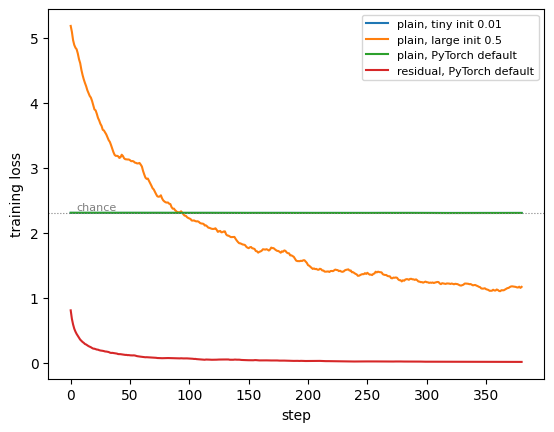

In [3]:
runs = {
    'plain, tiny init 0.01': run(gain=0.01),
    'plain, large init 0.5': run(gain=0.5),
    'plain, PyTorch default': run(),
    'residual, PyTorch default': run(residual=True),
}
for name, curve in runs.items():
    plt.plot(curve, label=name)
    print(f'{name:28s} final smoothed loss {curve[-1]:.3f}')
plt.axhline(np.log(10), color='grey', ls=':', lw=.8)
plt.text(5, np.log(10) * 1.02, 'chance', color='grey', fontsize=8)
plt.xlabel('step'); plt.ylabel('training loss'); plt.legend(fontsize=8); plt.show()

## 3--4. Clipping and schedules, at a rate that is too large

no clipping, constant rate   final smoothed loss 1.172
clipping at 1.0              final smoothed loss 1.035
warmup and cosine            final smoothed loss 1.447


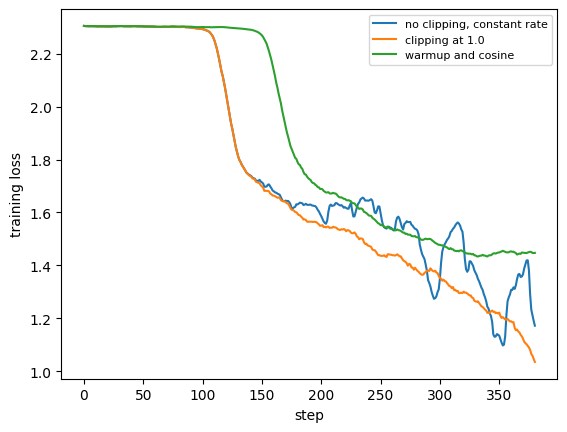

In [4]:
variants = {
    'no clipping, constant rate': run(lr=0.3),
    'clipping at 1.0': run(clip=1.0, lr=0.3),
    'warmup and cosine': run(schedule=True, lr=0.3),
}
for name, curve in variants.items():
    plt.plot(curve, label=name)
    print(f'{name:28s} final smoothed loss {curve[-1]:.3f}')
plt.xlabel('step'); plt.ylabel('training loss'); plt.legend(fontsize=8); plt.show()

## How often does clipping actually fire?

median 0.18, max 1.45, ratio 7.9x


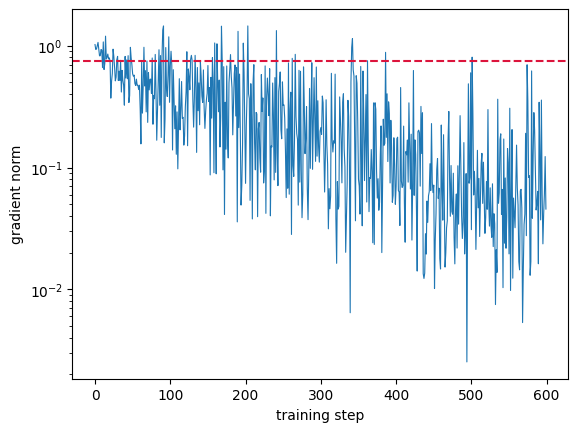

In [5]:
torch.manual_seed(11)
model = nn.Sequential(nn.Linear(64, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, 10))
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
loss_fn = nn.CrossEntropyLoss()
norms = []
for _ in range(600):
    index = torch.randint(0, len(X), (32,))
    loss = loss_fn(model(X[index]), y[index])
    optimizer.zero_grad(); loss.backward()
    norms.append(float(torch.sqrt(sum((p.grad ** 2).sum() for p in model.parameters()))))
    optimizer.step()
norms = np.array(norms)
c = np.quantile(norms, .90)
print(f'median {np.median(norms):.2f}, max {norms.max():.2f}, ratio {norms.max()/np.median(norms):.1f}x')
plt.plot(norms, lw=.8); plt.axhline(c, color='crimson', ls='--')
plt.yscale('log'); plt.xlabel('training step'); plt.ylabel('gradient norm'); plt.show()